In [1]:
# ============================================================
# MDCAT / MBBS Merit List PDF -> CSV extractor (Google Colab)
# Multi-year version: 2022-23, 2023-24, 2025-26 (DUHS Sindh)
# ============================================================
# Run each block as a separate Colab cell.


In [2]:
# ---- Cell 1: install dependencies ----
!pip install pdfplumber camelot-py[cv] pandas -q
!apt-get install -y ghostscript -q  # required by camelot


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 1.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 31.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 35.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 57.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 41.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 113.2/113.2 kB 4.1 MB/s eta 0:00:00
Reading package lists...
Building dependency tree...
Reading state information...
The following additional packages will be installed:
  fonts-droid-fallback fonts-noto-mono fonts-urw-base35 libgs-common libgs10
  libgs10-common libidn12 libijs-0.35 libjbig2dec0 poppler-data
  xfonts-encodings xfonts-utils
Suggested packages:
  fonts-noto fonts-freefont-otf | fonts-freefo

In [3]:
# ---- Cell 2: imports ----
import pdfplumber
import camelot
import pandas as pd
import re
import os
import requests


In [4]:
# ---- Cell 3: config — one entry per year's PDF ----
# NOTE: no 2024-25 Sindh MBBS PDF was found publicly at time of writing —
# DUHS appears to have skipped/merged that cycle in its public archive.
# 2022-23, 2023-24, and 2025-26 are confirmed available below.
# If you find a 2024-25 link later, just add a 4th dict here.
PDF_SOURCES = [
    {
        "name": "DUHS_Sindh_MBBS_2022_23",
        "url": "https://invent.ilmkidunya.com/images/Section/Final-Merit-List-of-MBBS-2022-23-dow.pdf",
        "year": 2022,
        "province": "Sindh",
    },
    {
        "name": "DUHS_Sindh_MBBS_2023_24",
        "url": "https://admissions.duhs.edu.pk/doc/Final%20Merit%20list%20MBBS%20Session%202023-24%20Public_291223.pdf",
        "year": 2023,
        "province": "Sindh",
    },
    {
        "name": "DUHS_Sindh_MBBS_2025_26",
        "url": "https://admissions.duhs.edu.pk/doc/Final%20Merit%20List%20of%20MBBS%20Program%20(Session%202025-26)%20Public%20Sector%20Medical%20Universities%20Colleges%20of%20Sindh%20Province%20All%20Districts%20of%20Karachi%20Division-2025.pdf",
        "year": 2025,
        "province": "Sindh",
    },
    # Add more dicts here for UHS Punjab, KMU KPK, etc. if you want cross-province data.
]

os.makedirs("pdfs", exist_ok=True)
os.makedirs("extracted", exist_ok=True)


In [5]:
# ---- Cell 4a: download PDFs by URL ----
def download_pdf(url, out_path):
    headers = {"User-Agent": "Mozilla/5.0"}
    r = requests.get(url, headers=headers, timeout=30)
    r.raise_for_status()
    with open(out_path, "wb") as f:
        f.write(r.content)
    print(f"Downloaded: {out_path} ({len(r.content)/1024:.0f} KB)")

for src in PDF_SOURCES:
    out_path = f"pdfs/{src['name']}.pdf"
    if not os.path.exists(out_path):
        try:
            download_pdf(src["url"], out_path)
        except Exception as e:
            print(f"FAILED to auto-download {src['name']}: {e}")
            print("-> Download it manually in your browser, then upload it to /pdfs/ in Colab's file panel.")

Downloaded: pdfs/DUHS_Sindh_MBBS_2022_23.pdf (4024 KB)
Downloaded: pdfs/DUHS_Sindh_MBBS_2023_24.pdf (646 KB)
Downloaded: pdfs/DUHS_Sindh_MBBS_2025_26.pdf (798 KB)


In [6]:
# ---- Cell 4b: (alternative) manually uploaded PDFs ----
# If a college's server blocks scripted downloads, do this instead:
#   1. Download the PDF yourself in your browser
#   2. In Colab, click the folder icon (left sidebar) -> upload into /content/pdfs/
#   3. Make sure the filename matches src['name'] + ".pdf" above.


In [7]:
# ---- Cell 5: table extraction (camelot first, pdfplumber fallback) ----
def extract_tables_camelot(pdf_path):
    try:
        tables = camelot.read_pdf(pdf_path, pages="all", flavor="lattice")
        if tables.n == 0:
            tables = camelot.read_pdf(pdf_path, pages="all", flavor="stream")
        dfs = [t.df for t in tables]
        return dfs
    except Exception as e:
        print(f"camelot failed on {pdf_path}: {e}")
        return []

def extract_tables_pdfplumber(pdf_path):
    dfs = []
    with pdfplumber.open(pdf_path) as pdf:
        for page in pdf.pages:
            table = page.extract_table()
            if table and len(table) > 1:
                df = pd.DataFrame(table[1:], columns=table[0])
                dfs.append(df)
    return dfs

def extract_pdf(pdf_path):
    dfs = extract_tables_camelot(pdf_path)
    if not dfs:
        print(f"Falling back to pdfplumber for {pdf_path}")
        dfs = extract_tables_pdfplumber(pdf_path)
    if dfs:
        return pd.concat(dfs, ignore_index=True)
    return pd.DataFrame()


In [8]:
# ---- Cell 6: run extraction over every PDF, tag with year/province ----
all_rows = []
for src in PDF_SOURCES:
    pdf_path = f"pdfs/{src['name']}.pdf"
    if not os.path.exists(pdf_path):
        print(f"Skipping {src['name']} — PDF not found (see Cell 4b).")
        continue
    print(f"Extracting {src['name']}...")
    df = extract_pdf(pdf_path)
    if df.empty:
        print(f"  -> No tables found in {src['name']}")
        continue
    df["source_file"] = src["name"]
    df["year"] = src["year"]
    df["province"] = src["province"]
    df.to_csv(f"extracted/{src['name']}_raw.csv", index=False)
    all_rows.append(df)
    print(f"  -> {len(df)} rows extracted")


Extracting DUHS_Sindh_MBBS_2022_23...
  -> 5185 rows extracted
Extracting DUHS_Sindh_MBBS_2023_24...
  -> 3773 rows extracted
Extracting DUHS_Sindh_MBBS_2025_26...
  -> 2800 rows extracted


In [9]:
# ---- Cell 7: clean and standardize columns ----
# Confirmed header row from earlier inspection:
# "Final Merit No | Candidate's Name | Father's Name |
#  Matric / O Level 10%(A) | Inter / A Level 40%(B) | MDCAT Marks 50%(C) | Total Aggregate (A+B+C)"
# This mapping is by keyword match, so it should hold across years since DUHS
# reuses the same table format — but ALWAYS check each year's raw CSV, since
# older PDFs (2022-23) are more likely to have layout drift.

def clean_merit_df(df, source_name):
    df = df.copy()

    # Save these BEFORE any column renaming touches them
    saved_meta = df[["source_file", "year", "province"]].copy()

    # Iterate through potential header rows (first 3 rows) to find the actual header
    header_row_idx = -1
    for i in range(min(df.shape[0], 3)): # Check up to the first 3 rows
        row_values = [str(x).strip().lower() for x in df.iloc[i].values]
        # Look for typical header keywords
        if any("candidate" in s and "name" in s for s in row_values) and \
           any("aggregate" in s or "total" in s for s in row_values):
            header_row_idx = i
            break

    if header_row_idx != -1:
        df.columns = df.iloc[header_row_idx]
        df = df[header_row_idx + 1:].reset_index(drop=True)
        # Adjust saved_meta if header was found in a row other than the first
        if header_row_idx > 0:
            saved_meta = saved_meta[header_row_idx + 1:].reset_index(drop=True)
    else:
        # Fallback if no clear header found, assume first row is header or use default numeric columns
        # In case the first column of row 0 is a known header, promote it
        first_cell = str(df.iloc[0, 0]).strip().lower()
        if first_cell in ("final merit no", "merit no", "sr no", "sr. no", "s.no", "s. no"):
            df.columns = df.iloc[0]
            df = df[1:].reset_index(drop=True)
            saved_meta = saved_meta[1:].reset_index(drop=True)
        else:
            # If still no header, columns remain numeric. Try to use common patterns.
            pass # Columns remain numeric (0, 1, 2...) for now, rename_map will attempt to match.

    # Clean column names (strip whitespace, lowercase, replace newlines)
    df.columns = [str(c).strip().replace('\n', ' ') for c in df.columns]

    rename_map = {}
    for c in df.columns:
        cl = c.lower()
        if "candidate" in cl and "name" in cl:
            rename_map[c] = "candidate_name"
        elif "matric" in cl or "o level" in cl:
            rename_map[c] = "matric_pct"
        elif "inter" in cl or "a level" in cl:
            rename_map[c] = "fsc_pct"
        elif "mdcat" in cl:
            rename_map[c] = "mdcat_pct"
        elif "aggregate" in cl or "total" in cl:
            rename_map[c] = "aggregate_pct"

    df = df.rename(columns=rename_map)

    keep_cols = [c for c in
                 ["candidate_name", "matric_pct", "fsc_pct", "mdcat_pct", "aggregate_pct"]
                 if c in df.columns]

    # Ensure saved_meta has the same number of rows as df after header removal and before dropping missing data
    if len(df) != len(saved_meta):
        # This should ideally not happen with correct header handling, but as a safeguard
        min_len = min(len(df), len(saved_meta))
        df = df.iloc[:min_len].reset_index(drop=True)
        saved_meta = saved_meta.iloc[:min_len].reset_index(drop=True)

    df = df[keep_cols].reset_index(drop=True)

    # Reattach the metadata now that column-name games are over
    df = pd.concat([df, saved_meta], axis=1)

    for c in ["matric_pct", "fsc_pct", "mdcat_pct", "aggregate_pct"]:
        if c in df.columns:
            # Handle common non-numeric characters before conversion
            df[c] = df[c].astype(str).str.replace(r"[^\d.\-\\s]", "", regex=True) # Allow hyphens and spaces for now
            df[c] = pd.to_numeric(df[c], errors="coerce")

    if "aggregate_pct" in df.columns:
        df = df.dropna(subset=["aggregate_pct"])
    else:
        print(f"Warning: 'aggregate_pct' column not found for {source_name}. Skipping dropna on this column.")

    return df

In [10]:
# ---- Cell 8: combine everything into ONE final CSV ----
cleaned_frames = []
for i, src in enumerate(PDF_SOURCES):
    # Ensure we don't try to access all_rows out of bounds if a PDF was skipped
    if i < len(all_rows):
        df_raw = all_rows[i]
        df_cleaned = clean_merit_df(df_raw, src["name"])
        if not df_cleaned.empty:
            cleaned_frames.append(df_cleaned)

if cleaned_frames:
    final_df = pd.concat(cleaned_frames, ignore_index=True)
    final_df = final_df.drop_duplicates()
    final_df.to_csv("mdcat_merit_combined.csv", index=False)
    print(f"\nFinal combined dataset: {len(final_df)} rows -> mdcat_merit_combined.csv")
    print(final_df.groupby("year").size())
    display(final_df.head(20))
else:
    print("No data extracted — check PDF sources and column mapping in Cell 7.")

from google.colab import files
files.download("mdcat_merit_combined.csv")


Final combined dataset: 10810 rows -> mdcat_merit_combined.csv
year
2022    4476
2023    3651
2025    2683
dtype: int64


,candidate_name,matric_pct,fsc_pct,mdcat_pct,aggregate_pct,source_file,year,province
0,Mutahharah Ahmad,9.609,38.266,47.25,95.125,DUHS_Sindh_MBBS_2022_23,2022,Sindh
1,Saba Saghir Malik,9.445,38.400,44.75,92.595,DUHS_Sindh_MBBS_2022_23,2022,Sindh
2,Shaikh Muhammad Daniyal,8.933,37.127,46.50,92.560,DUHS_Sindh_MBBS_2022_23,2022,Sindh
3,Syeda Zainab Ali,9.672,38.618,44.25,92.540,DUHS_Sindh_MBBS_2022_23,2022,Sindh
4,Ayesha Khan,9.000,36.690,46.75,92.440,DUHS_Sindh_MBBS_2022_23,2022,Sindh
5,Amnah Ashfaq,9.581,37.090,45.75,92.421,DUHS_Sindh_MBBS_2022_23,2022,Sindh
6,Fauzaan Ahmed Siddiqui,9.863,37.781,44.75,92.394,DUHS_Sindh_MBBS_2022_23,2022,Sindh
7,Simra Hasan,9.445,36.800,45.75,91.995,DUHS_Sindh_MBBS_2022_23,2022,Sindh
8,Fatima,9.481,37.745,44.75,91.976,DUHS_Sindh_MBBS_2022_23,2022,Sindh
9,Ayesha Jameel,9.709,37.636,44.50,91.845,DUHS_Sindh_MBBS_2022_23,2022,Sindh


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [11]:
# ============================================================
# MDCAT Merit Dataset — Inspection, EDA & Visualization
# ============================================================
# Run each block as a separate Colab cell.
# Assumes mdcat_merit_combined.csv is already uploaded/in Colab.


In [12]:
# ---- Cell 1: imports ----
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [13]:
sns.set_style("whitegrid")


In [14]:
# ---- Cell 2: load data ----
df = pd.read_csv("mdcat_merit_combined.csv")
print("Shape:", df.shape)
df.head()

Shape: (10810, 8)


,candidate_name,matric_pct,fsc_pct,mdcat_pct,aggregate_pct,source_file,year,province
0,Mutahharah Ahmad,9.609,38.266,47.25,95.125,DUHS_Sindh_MBBS_2022_23,2022,Sindh
1,Saba Saghir Malik,9.445,38.400,44.75,92.595,DUHS_Sindh_MBBS_2022_23,2022,Sindh
2,Shaikh Muhammad Daniyal,8.933,37.127,46.50,92.560,DUHS_Sindh_MBBS_2022_23,2022,Sindh
3,Syeda Zainab Ali,9.672,38.618,44.25,92.540,DUHS_Sindh_MBBS_2022_23,2022,Sindh
4,Ayesha Khan,9.000,36.690,46.75,92.440,DUHS_Sindh_MBBS_2022_23,2022,Sindh


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10810 entries, 0 to 10809
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   candidate_name  10810 non-null  object 
 1   matric_pct      10810 non-null  float64
 2   fsc_pct         10810 non-null  float64
 3   mdcat_pct       10810 non-null  float64
 4   aggregate_pct   10810 non-null  float64
 5   source_file     10810 non-null  object 
 6   year            10810 non-null  int64  
 7   province        10810 non-null  object 
dtypes: float64(4), int64(1), object(3)
memory usage: 675.8+ KB


In [16]:
df.isnull().sum()

,0
candidate_name,0
matric_pct,0
fsc_pct,0
mdcat_pct,0
aggregate_pct,0
source_file,0
year,0
province,0


In [17]:
df.duplicated().sum()

np.int64(0)

In [18]:
print("\nRows per year:\n", df.groupby("year").size())



Rows per year:
 year
2022    4476
2023    3651
2025    2683
dtype: int64


In [19]:
df.describe()

,matric_pct,fsc_pct,mdcat_pct,aggregate_pct,year
count,10810.000000,10810.000000,10810.000000,10810.000000,10810.000000
mean,8.593025,33.690517,36.377983,78.661525,2023.082331
std,0.676042,2.449583,4.517543,6.278253,1.183299
min,4.435000,19.333000,27.500000,55.960000,2022.000000
25%,8.200000,32.218000,33.000000,74.309000,2022.000000
50%,8.647000,33.927000,36.500000,79.269500,2023.000000
75%,9.035000,35.454000,39.750000,83.204000,2023.000000
max,10.000000,39.600000,49.444000,96.289000,2025.000000


In [20]:
# ---- Cell 4: sanity check — does aggregate = matric + fsc + mdcat? ----
diff = (df["aggregate_pct"] - (df["matric_pct"] + df["fsc_pct"] + df["mdcat_pct"])).abs()
print("Max deviation:", diff.max(), " Mean deviation:", diff.mean())
# Should be ~0 (floating point noise only) — confirms extraction/cleaning is correct.


Max deviation: 1.4210854715202004e-14  Mean deviation: 3.0932600504042846e-15


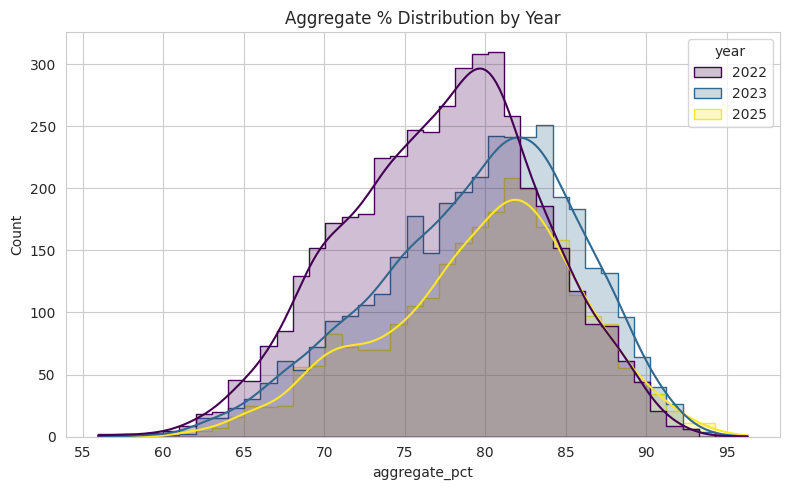

In [21]:
# ---- Cell 5a: Aggregate % Distribution by Year ----
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="aggregate_pct", hue="year", bins=40, kde=True,
             element="step", palette="viridis")
plt.title("Aggregate % Distribution by Year")
plt.tight_layout()
plt.savefig("fig1a_distribution.png", dpi=150)
plt.show()


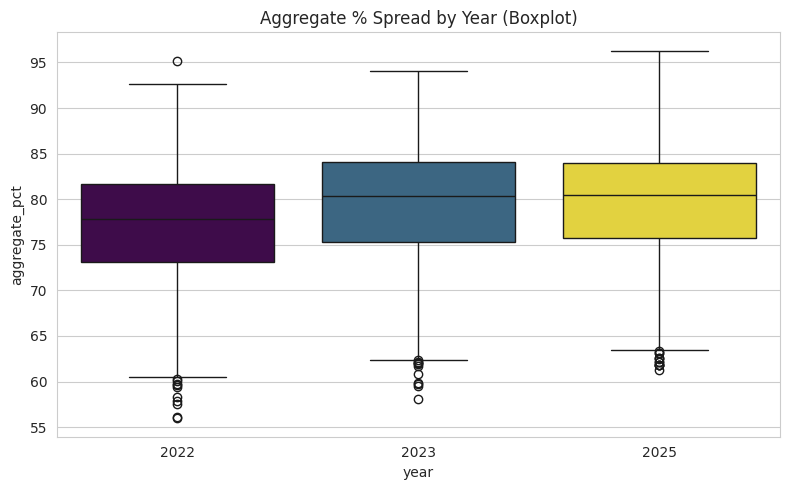

In [22]:
# ---- Cell 5b: Aggregate % Spread by Year (Boxplot) ----
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="year", y="aggregate_pct", hue="year",
            palette="viridis", legend=False)
plt.title("Aggregate % Spread by Year (Boxplot)")
plt.tight_layout()
plt.savefig("fig1b_boxplot.png", dpi=150)
plt.show()


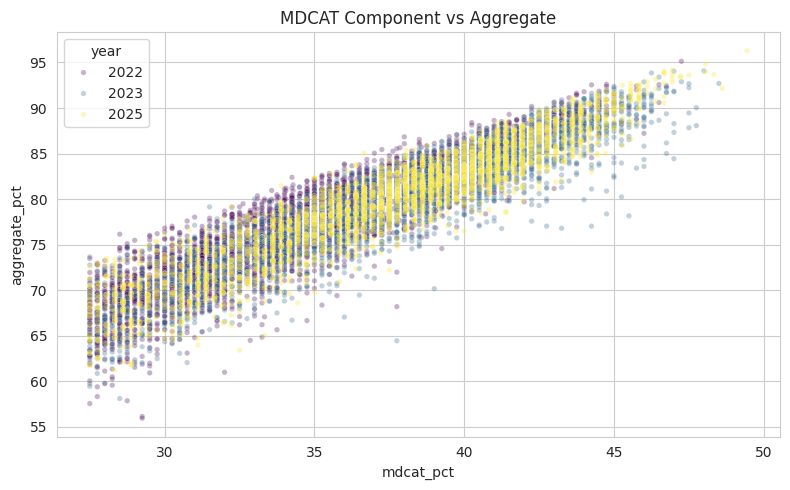

In [23]:
# ---- Cell 5c: MDCAT Component vs Aggregate ----
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="mdcat_pct", y="aggregate_pct", hue="year",
                 alpha=0.3, s=15, palette="viridis")
plt.title("MDCAT Component vs Aggregate")
plt.tight_layout()
plt.savefig("fig1c_scatter.png", dpi=150)
plt.show()


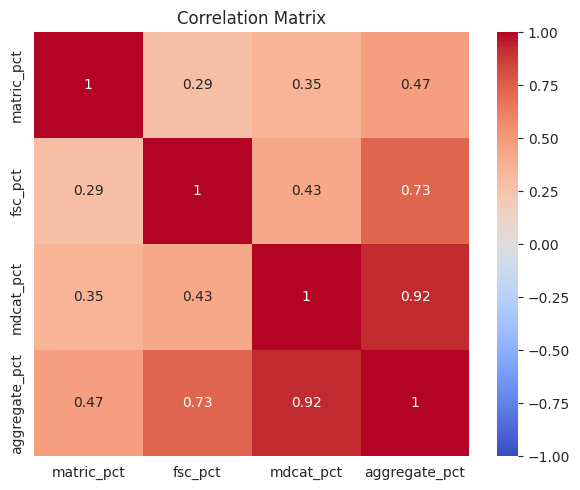

In [24]:
# ---- Cell 5d: Correlation Matrix ----
plt.figure(figsize=(6, 5))
corr = df[["matric_pct", "fsc_pct", "mdcat_pct", "aggregate_pct"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.savefig("fig1d_correlation.png", dpi=150)
plt.show()

In [25]:
# ---- Cell 6a: yearly stats table ----
yearly_stats = df.groupby("year")["aggregate_pct"].agg(["min", "mean", "max", "std"])
print(yearly_stats)


         min       mean     max       std
year                                     
2022  55.960  77.374690  95.125  6.103163
2023  58.122  79.486782  94.090  6.281425
2025  61.238  79.685328  96.289  6.186236


<Figure size 800x500 with 0 Axes>

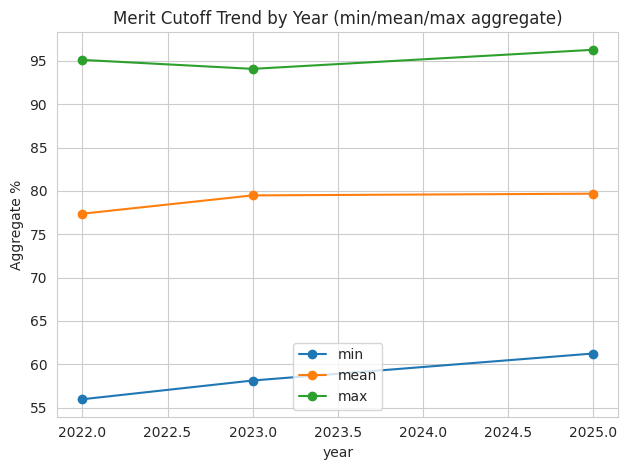

In [26]:
# ---- Cell 6b: Merit Cutoff Trend by Year (min/mean/max aggregate) ----
plt.figure(figsize=(8, 5))
yearly_stats[["min", "mean", "max"]].plot(marker="o")
plt.title("Merit Cutoff Trend by Year (min/mean/max aggregate)")
plt.ylabel("Aggregate %")
plt.tight_layout()
plt.savefig("fig2a_cutoff_trend.png", dpi=150)
plt.show()


<Figure size 800x500 with 0 Axes>

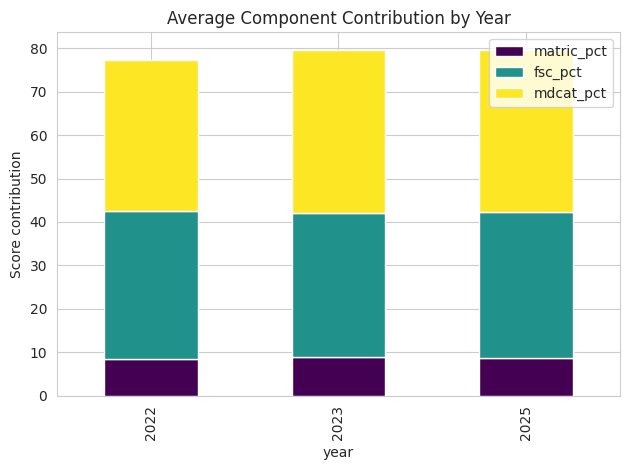

In [27]:
# ---- Cell 6c: Average Component Contribution by Year ----
comp_means = df.groupby("year")[["matric_pct", "fsc_pct", "mdcat_pct"]].mean()

plt.figure(figsize=(8, 5))
comp_means.plot(kind="bar", stacked=True, colormap="viridis")
plt.title("Average Component Contribution by Year")
plt.ylabel("Score contribution")
plt.tight_layout()
plt.savefig("fig2b_component_contribution.png", dpi=150)
plt.show()

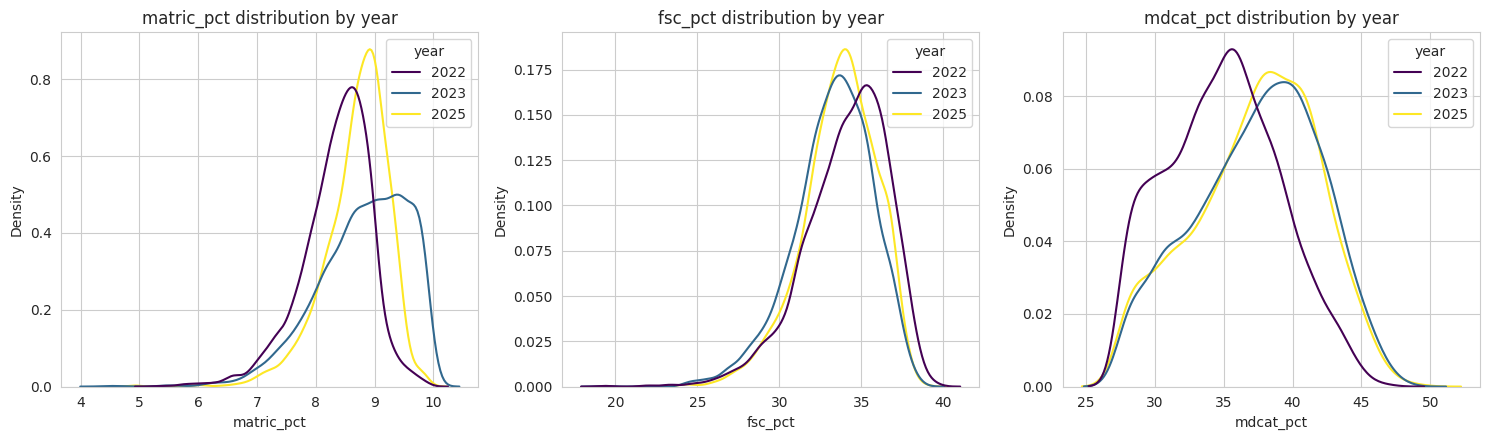

In [28]:
# ---- Cell 7: Figure 3 — per-component distributions across years ----
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, col in zip(axes, ["matric_pct", "fsc_pct", "mdcat_pct"]):
    sns.kdeplot(data=df, x=col, hue="year", ax=ax, palette="viridis", common_norm=False)
    ax.set_title(f"{col} distribution by year")
plt.tight_layout()
plt.savefig("fig3_components.png", dpi=150)
plt.show()


In [29]:
# ---- Cell 8: numeric insights — variation & correlation ----
print("=== Coefficient of variation (std/mean) per component ===")
for col in ["matric_pct", "fsc_pct", "mdcat_pct"]:
    cv = df[col].std() / df[col].mean()
    print(f"{col}: CV={cv:.4f}")

print("\n=== Correlation with aggregate ===")
print(corr["aggregate_pct"])


=== Coefficient of variation (std/mean) per component ===
matric_pct: CV=0.0787
fsc_pct: CV=0.0727
mdcat_pct: CV=0.1242

=== Correlation with aggregate ===
matric_pct       0.474477
fsc_pct          0.728163
mdcat_pct        0.923907
aggregate_pct    1.000000
Name: aggregate_pct, dtype: float64


In [30]:
# ---- Cell 9: top vs bottom 10% comparison ----
top10 = df[df["aggregate_pct"] >= df["aggregate_pct"].quantile(0.9)]
bottom10 = df[df["aggregate_pct"] <= df["aggregate_pct"].quantile(0.1)]

print("Top 10% component means:\n", top10[["matric_pct", "fsc_pct", "mdcat_pct"]].mean())
print("\nBottom 10% component means:\n", bottom10[["matric_pct", "fsc_pct", "mdcat_pct"]].mean())

comparison = pd.DataFrame({
    "Top 10%": top10[["matric_pct", "fsc_pct", "mdcat_pct"]].mean(),
    "Bottom 10%": bottom10[["matric_pct", "fsc_pct", "mdcat_pct"]].mean(),
})
comparison["Gap"] = comparison["Top 10%"] - comparison["Bottom 10%"]
print("\n", comparison)


Top 10% component means:
 matric_pct     9.107972
fsc_pct       36.154780
mdcat_pct     43.418054
dtype: float64

Bottom 10% component means:
 matric_pct     7.934340
fsc_pct       29.674229
mdcat_pct     29.485624
dtype: float64

               Top 10%  Bottom 10%        Gap
matric_pct   9.107972    7.934340   1.173633
fsc_pct     36.154780   29.674229   6.480551
mdcat_pct   43.418054   29.485624  13.932429


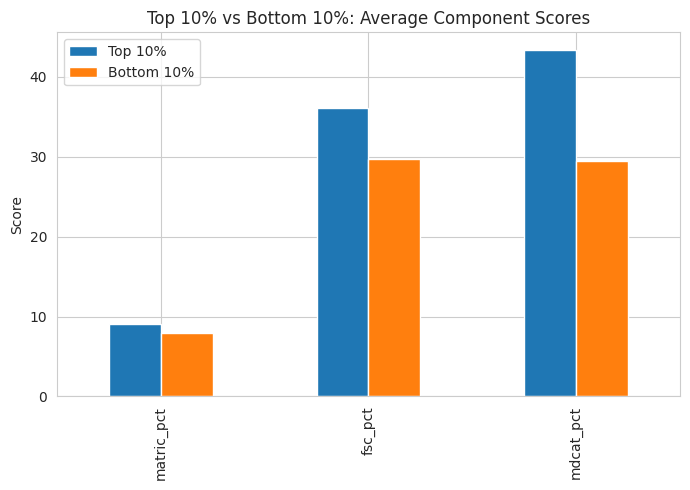

In [31]:
comparison[["Top 10%", "Bottom 10%"]].plot(kind="bar", figsize=(7, 5))
plt.title("Top 10% vs Bottom 10%: Average Component Scores")
plt.ylabel("Score")
plt.tight_layout()
plt.savefig("fig4_top_vs_bottom.png", dpi=150)
plt.show()


In [32]:
# ============================================================
# Part A — Investigate the 2022 anomaly flagged in EDA
# ============================================================


In [33]:
# ---- Cell A1: lowest matric/mdcat rows in 2022 specifically ----
df_2022 = df[df["year"] == 2022]

print("Lowest 15 matric_pct in 2022:")
print(df_2022.nsmallest(15, "matric_pct")[["candidate_name", "matric_pct", "fsc_pct", "mdcat_pct", "aggregate_pct"]])

print("\nLowest 15 mdcat_pct in 2022:")
print(df_2022.nsmallest(15, "mdcat_pct")[["candidate_name", "matric_pct", "fsc_pct", "mdcat_pct", "aggregate_pct"]])


Lowest 15 matric_pct in 2022:
                candidate_name  matric_pct  fsc_pct  mdcat_pct  aggregate_pct
4457            Ramsha Manzoor       5.255   26.933      29.50         61.688
4070              Usama Yaqoob       5.419   31.666      31.75         68.835
4081               Saima Rahim       5.494   35.266      28.00         68.760
3745        Naina Sher Balouch       5.694   36.733      28.50         70.927
4453              Sumaiya Arif       5.694   28.836      27.50         62.030
2834                     Vinod       5.705   36.763      33.00         75.468
4470             Alishba Anwar       5.764   25.890      27.75         59.404
4341  Fareeha Nadeem Ur Rehman       5.788   30.866      29.00         65.654
4105             Rajmeena Aziz       5.823   29.533      33.25         68.606
3513              Adeeba Sahar       5.854   33.127      33.25         72.231
4430           Muhammad Junaid       5.877   29.600      27.75         63.227
4177             Ayesha Arshad    

In [34]:
# ---- Cell A2: compare tail density across years (is it a few rows or a real cluster?) ----
for yr in [2022, 2023, 2025]:
    sub = df[df["year"] == yr]
    low_matric_count = (sub["matric_pct"] < 7).sum()
    low_mdcat_count = (sub["mdcat_pct"] < 30).sum()
    print(f"Year {yr}: matric_pct<7 -> {low_matric_count} rows ({low_matric_count/len(sub)*100:.1f}%), "
          f"mdcat_pct<30 -> {low_mdcat_count} rows ({low_mdcat_count/len(sub)*100:.1f}%)")


Year 2022: matric_pct<7 -> 111 rows (2.5%), mdcat_pct<30 -> 608 rows (13.6%)
Year 2023: matric_pct<7 -> 67 rows (1.8%), mdcat_pct<30 -> 237 rows (6.5%)
Year 2025: matric_pct<7 -> 18 rows (0.7%), mdcat_pct<30 -> 202 rows (7.5%)


In [35]:
# ============================================================
# Part B — Feature engineering + corrected target
# ============================================================


In [36]:
# ---- Cell B1: build the feature set ----
# aggregate_pct is EXCLUDED — it's matric_pct + fsc_pct + mdcat_pct by definition,
# so using it as a feature would leak the target, and using it as the target makes
# the "model" just arithmetic. It stays in the CSV for reference only.

df_model = df.copy()
df_model["matric_fsc_interaction"] = df_model["matric_pct"] * df_model["fsc_pct"]

features = ["matric_pct", "fsc_pct", "matric_fsc_interaction"]
target = "mdcat_pct"


In [37]:
print(df_model[features + [target]].describe())


         matric_pct       fsc_pct  matric_fsc_interaction     mdcat_pct
count  10810.000000  10810.000000            10810.000000  10810.000000
mean       8.593025     33.690517              289.982870     36.377983
std        0.676042      2.449583               34.582560      4.517543
min        4.435000     19.333000              132.059012     27.500000
25%        8.200000     32.218000              268.842265     33.000000
50%        8.647000     33.927000              294.059659     36.500000
75%        9.035000     35.454000              314.322421     39.750000
max       10.000000     39.600000              377.741000     49.444000


In [38]:
print("\nCorrelation of each feature with target (mdcat_pct):")
print(df_model[features + [target]].corr()[target])



Correlation of each feature with target (mdcat_pct):
matric_pct                0.352762
fsc_pct                   0.426399
matric_fsc_interaction    0.486998
mdcat_pct                 1.000000
Name: mdcat_pct, dtype: float64


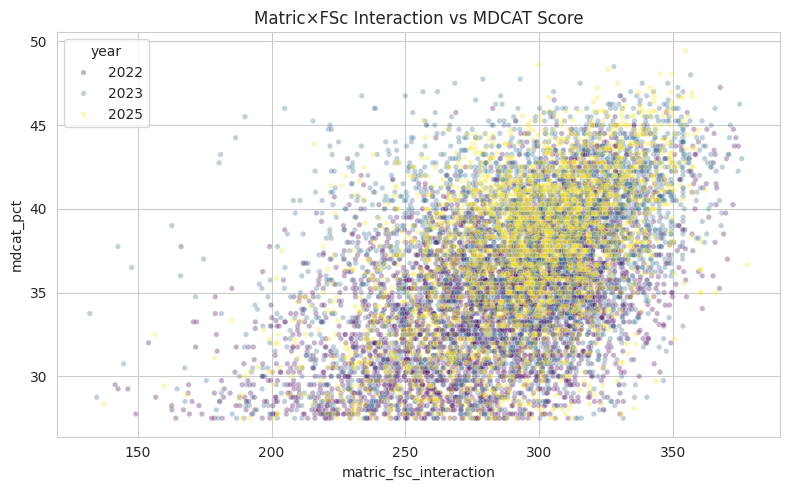

In [39]:
# ---- Cell B2: visualize the actual (non-trivial) relationship ----
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_model, x="matric_fsc_interaction", y="mdcat_pct", hue="year",
                 alpha=0.3, s=15, palette="viridis")
plt.title("Matric×FSc Interaction vs MDCAT Score")
plt.tight_layout()
plt.savefig("fig5_interaction_vs_mdcat.png", dpi=150)
plt.show()


In [40]:
# ---- Cell B3: train/test split — YEAR-BASED (train on past, test on most recent year) ----
train_df = df_model[df_model["year"].isin([2022, 2023])]
test_df = df_model[df_model["year"] == 2025]

X_train = train_df[features].values
y_train = train_df[target].values
X_test = test_df[features].values
y_test = test_df[target].values

print(f"Train rows: {len(X_train)} (2022+2023)  |  Test rows: {len(X_test)} (2025)")


Train rows: 8127 (2022+2023)  |  Test rows: 2683 (2025)


In [41]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [42]:
# ============================================================
# Part C — Model training: predict mdcat_pct from academic history
# Train: 2022+2023 | Test: 2025 (year-based split, real generalization test)
# ============================================================


In [43]:
# ---- Cell C1: install/import ----
!pip install xgboost scikit-learn tensorflow -q


In [44]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

# NOTE: this assumes Part B already ran in this session, so X_train, X_test,
# y_train, y_test, X_train_scaled, X_test_scaled, features, target all exist.


In [45]:
def report(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{name}: MAE={mae:.4f}  RMSE={rmse:.4f}  R2={r2:.4f}")
    return {"model": name, "MAE": mae, "RMSE": rmse, "R2": r2}

results = []


In [46]:
# ---- Cell C2: Baseline 1 — Linear Regression ----
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
results.append(report("Linear Regression", y_test, lr_pred))

print("\nCoefficients:")
for f, c in zip(features, lr.coef_):
    print(f"  {f}: {c:.4f}")


Linear Regression: MAE=3.2677  RMSE=3.9735  R2=0.2197

Coefficients:
  matric_pct: -5.1669
  fsc_pct: -1.0798
  matric_fsc_interaction: 0.2032


In [47]:
# ---- Cell C3: Baseline 2 — XGBoost ----
xgb = XGBRegressor(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, random_state=42
)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)
results.append(report("XGBoost", y_test, xgb_pred))


XGBoost: MAE=3.3644  RMSE=4.0873  R2=0.1743


In [48]:
# ---- Cell C4 (revised): simpler ANN — less regularization for 3 features ----
tf.random.set_seed(42)

ann = models.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(32, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="linear"),
])

In [49]:

# Changes from before:
#  - Removed both Dropout layers: with only 3 features, dropout was throwing
#    away too much signal on every forward pass, pushing the network toward
#    predicting near the mean instead of tracking the actual relationship.
#  - Reduced width (64->32, 32->16): a 3-feature problem doesn't need a
#    64-unit first layer; that much capacity + dropout was likely fighting
#    itself rather than helping.

ann.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
            loss="mse", metrics=["mae"])
# Switched Huber -> MSE: Huber's robustness to outliers matters when outliers
# are errors/noise you want to downweight. Here your "outliers" (high MDCAT
# scorers) are exactly the cases you most want the model to get right, so
# Huber may have been actively discouraging the model from fitting them.

early_stop = callbacks.EarlyStopping(monitor="val_loss", patience=20, restore_best_weights=True)
reduce_lr = callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=8)

history = ann.fit(
    X_train_scaled, y_train,
    validation_split=0.15,
    epochs=300,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1,
)



Epoch 1/300
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 886.0914 - mae: 28.2831 - val_loss: 205.7263 - val_mae: 12.7367 - learning_rate: 0.0010
Epoch 2/300
216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 116.7024 - mae: 8.8016 - val_loss: 72.0236 - val_mae: 5.9249 - learning_rate: 0.0010
Epoch 3/300
216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 37.0167 - mae: 4.7167 - val_loss: 36.2634 - val_mae: 4.5046 - learning_rate: 0.0010
Epoch 4/300
216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 19.5643 - mae: 3.5050 - val_loss: 30.7232 - val_mae: 4.4158 - learning_rate: 0.0010
Epoch 5/300
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 16.2408 - mae: 3.2208 - val_loss: 29.2721 - val_mae: 4.4037 - learning_rate: 0.0010
Epoch 6/300
216/216 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 15.5088 - mae: 3.1550 - val_loss: 27.8836 - val_mae: 4.3379 - learning_rate: 0.0010
Epoch 7/300
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 15.2377 - mae: 3.1312 - val_loss: 26.6263 - val_mae: 4.2567 - 

In [50]:
ann_pred = ann.predict(X_test_scaled).flatten()
results = [r for r in results if r["model"] != "ANN"]  # drop old ANN result if re-running
results.append(report("ANN", y_test, ann_pred))

84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
ANN: MAE=3.2967  RMSE=4.0140  R2=0.2037


In [51]:
results_df = pd.DataFrame(results)
print(results_df)

               model       MAE      RMSE        R2
0  Linear Regression  3.267725  3.973465  0.219684
1            XGBoost  3.364362  4.087325  0.174323
2                ANN  3.296697  4.013971  0.203693


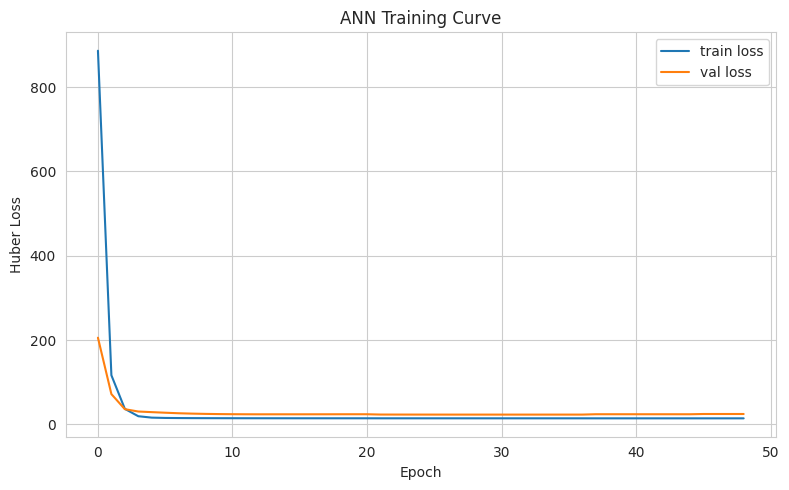

In [52]:
# ---- Cell C5: training curve ----
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="val loss")
plt.xlabel("Epoch")
plt.ylabel("Huber Loss")
plt.title("ANN Training Curve")
plt.legend()
plt.tight_layout()
plt.savefig("fig6_ann_training_curve.png", dpi=150)
plt.show()


In [53]:
# ---- Cell C6: comparison table ----
results_df = pd.DataFrame(results)
print(results_df)
results_df.to_csv("model_comparison_mdcat_target.csv", index=False)


               model       MAE      RMSE        R2
0  Linear Regression  3.267725  3.973465  0.219684
1            XGBoost  3.364362  4.087325  0.174323
2                ANN  3.296697  4.013971  0.203693


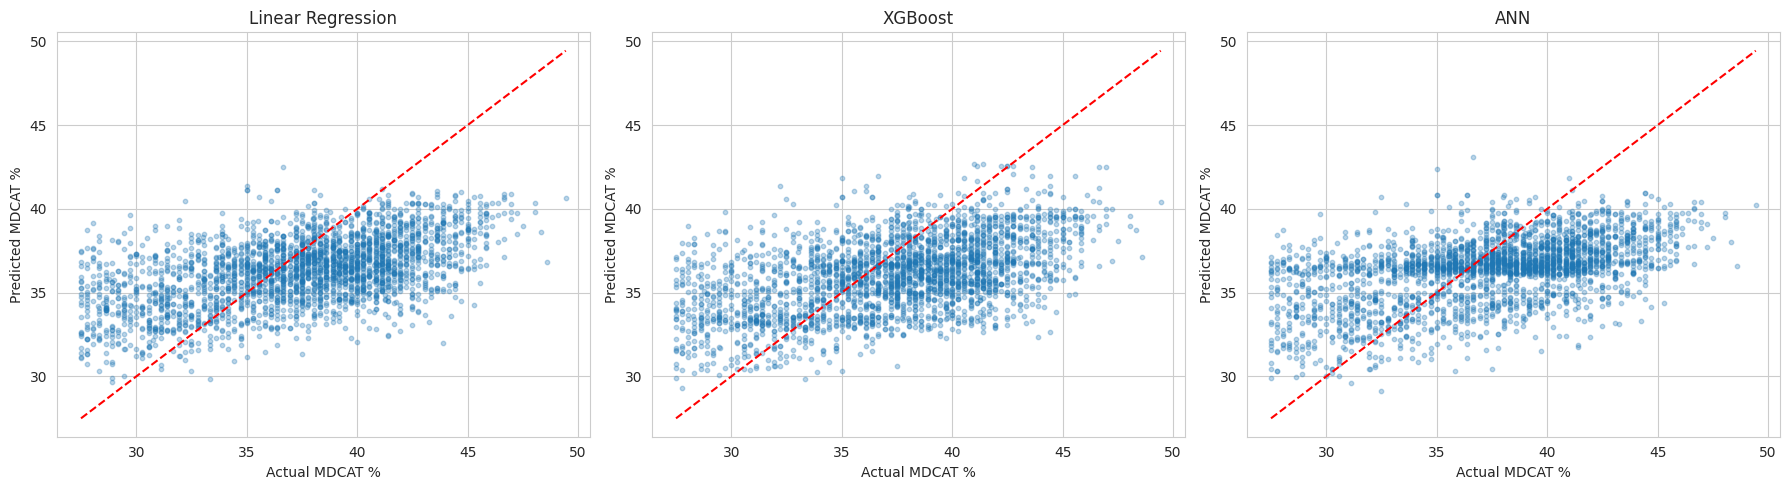

In [54]:
# ---- Cell C7: predicted vs actual (all 3 models) ----
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
preds = {"Linear Regression": lr_pred, "XGBoost": xgb_pred, "ANN": ann_pred}

for ax, (name, pred) in zip(axes, preds.items()):
    ax.scatter(y_test, pred, alpha=0.3, s=10)
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
    ax.set_xlabel("Actual MDCAT %")
    ax.set_ylabel("Predicted MDCAT %")
    ax.set_title(name)

plt.tight_layout()
plt.savefig("fig7_predicted_vs_actual_mdcat.png", dpi=150)
plt.show()


In [55]:
# ---- Cell C8: feature importance (XGBoost) ----
importances = pd.Series(xgb.feature_importances_, index=features).sort_values(ascending=False)
print(importances)


fsc_pct                   0.407553
matric_fsc_interaction    0.366742
matric_pct                0.225705
dtype: float32


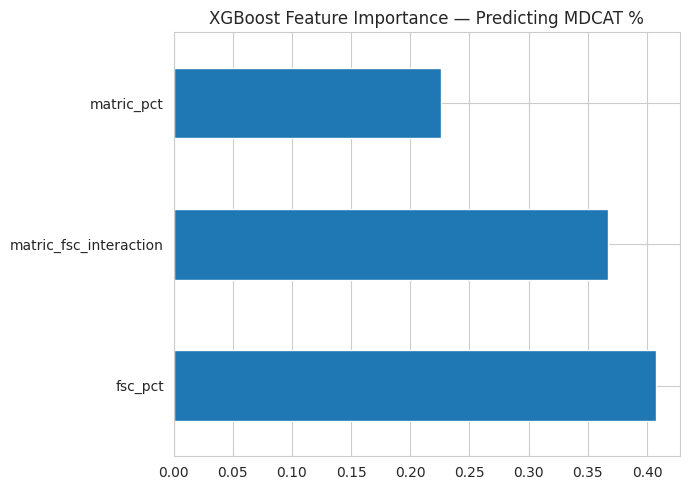

In [56]:
plt.figure(figsize=(7, 5))
importances.plot(kind="barh")
plt.title("XGBoost Feature Importance — Predicting MDCAT %")
plt.tight_layout()
plt.savefig("fig8_feature_importance.png", dpi=150)
plt.show()

In [57]:
# ---- Cell C9: Actual vs Predicted table (test set, all 3 models) ----

comparison_table = pd.DataFrame({
    "candidate_name": test_df["candidate_name"].values,
    "matric_pct": test_df["matric_pct"].values,
    "fsc_pct": test_df["fsc_pct"].values,
    "actual_mdcat_pct": y_test,
    "predicted_lr": lr_pred,
    "predicted_xgb": xgb_pred,
    "predicted_ann": ann_pred,
})


In [58]:
# Add per-model absolute error columns — useful for spotting where each model struggles
comparison_table["error_lr"] = (comparison_table["actual_mdcat_pct"] - comparison_table["predicted_lr"]).abs()
comparison_table["error_xgb"] = (comparison_table["actual_mdcat_pct"] - comparison_table["predicted_xgb"]).abs()
comparison_table["error_ann"] = (comparison_table["actual_mdcat_pct"] - comparison_table["predicted_ann"]).abs()


In [59]:


# Round for readability
comparison_table = comparison_table.round(2)

print(f"Test set size: {len(comparison_table)}")
comparison_table.to_csv("actual_vs_predicted_test_set.csv", index=False)

# Preview first 20 rows
display(comparison_table.head(20))

# ---- Cell C10: worst predictions per model (useful for your README error analysis) ----
print("Top 10 worst predictions — Linear Regression:")
display(comparison_table.nlargest(10, "error_lr")[["candidate_name", "actual_mdcat_pct", "predicted_lr", "error_lr"]])

print("\nTop 10 worst predictions — ANN:")
display(comparison_table.nlargest(10, "error_ann")[["candidate_name", "actual_mdcat_pct", "predicted_ann", "error_ann"]])


Test set size: 2683


,candidate_name,matric_pct,fsc_pct,actual_mdcat_pct,predicted_lr,predicted_xgb,predicted_ann,error_lr,error_xgb,error_ann
0,Fahad Shahid,9.50,37.34,49.44,40.66,40.419998,40.259998,8.79,9.02,9.18
1,Muhammad Rayyan Humayun,9.34,37.45,48.06,40.35,39.610001,39.750000,7.71,8.45,8.31
2,Alina Javed,9.45,37.78,46.94,40.91,42.509998,40.430000,6.03,4.44,6.51
3,Hiba Imran Jilani,9.30,38.04,46.67,40.73,40.430000,40.070000,5.94,6.23,6.60
4,Mahnoor Shahnawaz,9.48,36.40,48.06,39.81,38.950001,39.540001,8.25,9.10,8.52
5,Usman Ajmal Azim,9.45,37.78,46.67,40.91,42.509998,40.430000,5.76,4.16,6.23
6,Ayesha Asif,9.35,37.71,46.67,40.60,41.230000,40.009998,6.07,5.43,6.66
7,Khadijah Misbah Siddiqui,9.34,37.42,46.94,40.32,39.610001,39.720001,6.63,7.34,7.22
8,Fuzail Ashraf Khan,8.96,36.36,48.33,38.63,38.730000,38.049999,9.71,9.60,10.29
9,Aisha,8.84,37.27,47.50,38.99,38.060001,38.259998,8.51,9.44,9.24


Top 10 worst predictions — Linear Regression:


,candidate_name,actual_mdcat_pct,predicted_lr,error_lr
406,Tahir Hussain,43.89,31.99,11.90
24,Syed Mehmood Khan,48.61,36.84,11.77
2204,Taaiba Tanweer,28.06,39.17,11.11
409,Chaudhry Shayan Bin Hannan,45.28,34.28,11.00
2268,Wajiha Soomro,27.78,38.75,10.97
856,Hammad Ali,44.25,33.62,10.63
511,Ahsan Ashfaque,44.72,34.52,10.20
2210,Muhammad Qasim,28.33,38.41,10.08
1021,Sufwan Bin Nayab,43.25,33.24,10.01
2365,Aamna Mustafa,27.50,37.50,10.00



Top 10 worst predictions — ANN:


,candidate_name,actual_mdcat_pct,predicted_ann,error_ann
24,Syed Mehmood Khan,48.61,36.580002,12.03
856,Hammad Ali,44.25,33.310001,10.94
409,Chaudhry Shayan Bin Hannan,45.28,34.389999,10.89
2204,Taaiba Tanweer,28.06,38.759998,10.70
2268,Wajiha Soomro,27.78,38.459999,10.68
511,Ahsan Ashfaque,44.72,34.119999,10.60
8,Fuzail Ashraf Khan,48.33,38.049999,10.29
1021,Sufwan Bin Nayab,43.25,33.150002,10.10
70,Jazib Jamal,46.67,36.709999,9.95
2052,Misbah Rajput,29.72,39.669998,9.95
